# HW 3: STFT, Features, and Regression (15 points)

For each markdown cell, add a cell (or cells) of code below. 
Reminders:
* This is an individual assignment. 
* If you use GenAI tools to assist you with your homework, remember to fill out the GenAI Usage Statement at the bottom of the notebook. Even if you use GenAI, you should not be directly copying the code.
* You may only use functions/packages we have discussed in class

In [184]:
from scipy.stats import ttest_ind
from scipy.io.wavfile import read
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import librosa
import math

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

Read in the following files from your "audio" folder.
- /audio/country.00000.wav
- /audio/hiphop.00000.wav
    
Ensure that amplitudes are normalized to between -1 and 1.

In [185]:
fs_c, country = read('../audio/country.00000.wav')
fs_h, hiphop = read('../audio/hiphop.00000.wav')

country = country / max(np.abs(country))
hiphop = hiphop / max(np.abs(hiphop))

## Part 1: STFT parameters and visualization (6 points)

#### Write your own STFT (3 points)

Write your own STFT function that will output a 2D matrix with shape (num_frames, num_bins), where each row contains the DFT of a single frame.

* Use a hop size equal to half the frame size (i.e., hop_size = frame_size // 2) so that frames overlap by 50%, and you should apply a hanning window to each frame (you may use `np.hanning()` for this.)

* The user should be able to vary the size of the frame (leave hop_size fixed at 50%).

*Note: You should use the built in numpy FFT function (instead of your DFT). This means you will have to work in powers of 2!*

In [186]:
# your code here
def my_stft(audio_input, frame_size, sampling_rate = 44100):
    
    # Define frame_length (should be power of two based on input frame_size)
    frame_length = 2**(math.ceil(np.log2(frame_size)))

    # Define hop size is half the frame size
    hop_length = frame_length // 2

    # Define number of frames (m) we can extract with 50% overlap based on the total length of our signal
    # If the signal does not fit an integer number of frames, truncate
    n_mbins = len(audio_input) // hop_length - 1

    # Define total number of frequency bins
    n_kbins = hop_length + 1

    # Pre-allocate matrix for STFT. Remember it should be structured as [time_frames, frequency_bins]
    stft_matrix = np.zeros((n_mbins, n_kbins))

    # Define window
    window = np.hanning(frame_length)

    # Iterate through signal by frame
    for m in range(n_mbins):
        # index into the frame, apply window, apply fft over the frame, store in matrix
        frame = audio_input[m * hop_length:m * hop_length + frame_length]
        fft = np.fft.rfft(frame * window)
        stft_matrix[m, :] = np.abs(fft)

    return stft_matrix


#### Apply your STFT function

Apply your STFT function to the audio files listed above (country and hiphop)

In [187]:
frame_length = 512
hop_length = 256

country_stft = my_stft(country, frame_length, fs_c)
hiphop_stft = my_stft(hiphop, frame_length, fs_h)

country_stft, hiphop_stft

(array([[3.80535586e+00, 6.99184687e+00, 3.87518051e+01, ...,
         3.12403890e-01, 5.02475730e-02, 2.08388418e-01],
        [3.76301978e+00, 1.12922074e+01, 4.31168993e+01, ...,
         2.28594308e-01, 6.81071205e-02, 1.42351819e-02],
        [6.03575732e-01, 1.35406151e+01, 4.59743339e+01, ...,
         9.94236273e-02, 8.28274062e-02, 7.21998756e-02],
        ...,
        [4.92740920e+00, 2.22902705e+01, 3.29723273e+01, ...,
         1.31899615e-01, 1.97860379e-01, 3.82426079e-01],
        [9.59966077e-01, 4.34414404e+00, 1.66499901e+01, ...,
         7.43500359e-02, 2.13368274e-01, 3.05844737e-01],
        [2.88457853e+00, 1.02807382e+01, 2.50647066e+01, ...,
         9.02523932e-02, 1.24843051e-01, 7.95294177e-02]]),
 array([[8.38655694e+00, 4.52882557e+00, 2.44389577e-01, ...,
         1.63850082e-04, 1.86675038e-04, 4.72291192e-05],
        [8.10406790e+00, 3.83753070e+00, 6.14539450e-01, ...,
         5.32290898e-05, 6.60720086e-05, 1.52940974e-04],
        [5.28373584e+00, 

#### Write your own spectrogram function (3 points)

Write your own spectrogram function (using `plt.pcolormesh()`) called `plot_spectrogram()` that takes the complex-valued STFT output from your above function, and the sampling rate, and plots a magnitude spectrogram in decibels.

The axes should be properly labeled (time on x-axis, Frequency on y-axis).

*Note: audio processing workflows and dataframe logic in general in Python commonly use rows = time. However, several plotting functions like pcolormesh() annoyingly expect rows = frequency and columns = time. Therefore, we simply add a step to 'transpose' our 2d array or matrix in our code below.*


In [188]:
# your code here
def plot_spectrogram(stft_matrix, frame_size, sampling_rate):

    # Take magnitude and convert to decibels
    magnitude = np.abs(stft_matrix).T  # Transpose so rows = frequencies
    magnitude_db = 20 * np.log10(magnitude + 1e-6)  # avoid log(0)

    # Time and frequency axes
    num_frames = stft_matrix.shape[0] # total number of frames
    hop_size = frame_size // 2   # recall it was 50% of the frame size
    duration = hop_size * (num_frames + 1) / sampling_rate  # find duration
    
    # Make a time axis by taking the total duration and dividing the timeline according to the number of frames:
    time_axis = np.arange(num_frames) * hop_size / sampling_rate
    # Ditto for frequency axis according to the number of bins
    freq_axis = np.arange(stft_matrix.shape[1]) * sampling_rate / frame_size

    # Plot only up to Nyquist frequency by indexing your magnitude vector
    plt.ylim(0, sampling_rate / 2)
    plt.pcolormesh(time_axis, freq_axis, magnitude_db)

Plot the spectrogram of the country and hiphop audio files

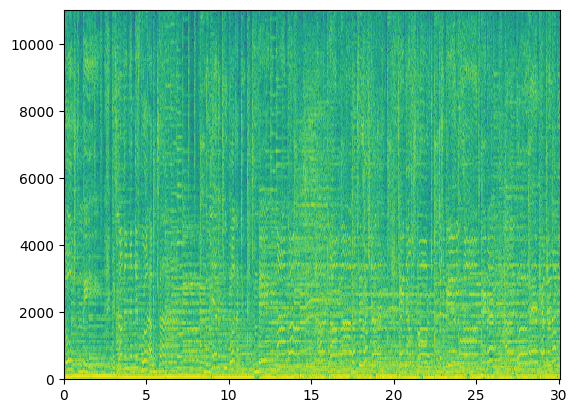

In [189]:
plot_spectrogram(country_stft, frame_length, fs_c)

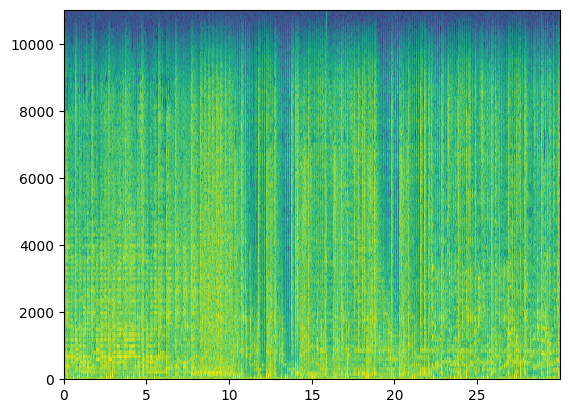

In [190]:
plot_spectrogram(hiphop_stft, frame_length, fs_h)

## Part 2: Feature Extraction (4 points)

We will perform feature extraction and compare the two audio files above.

Extract the following features for each file (you may use librosa functions):
- RMSE
- Spectral Centroid
- Spectral Flux
- ZCR

For each feature:
- graph the results of each feature
- briefly describe what the feature might tell us perceptually
- briefly describe whether or not this might be a useful feature for classification (based on the graphs)

1 point for each correct feature calculation and associated explanation/reasoning

Text(0.5, 1.0, 'RMSE of HipHop vs Country Track')

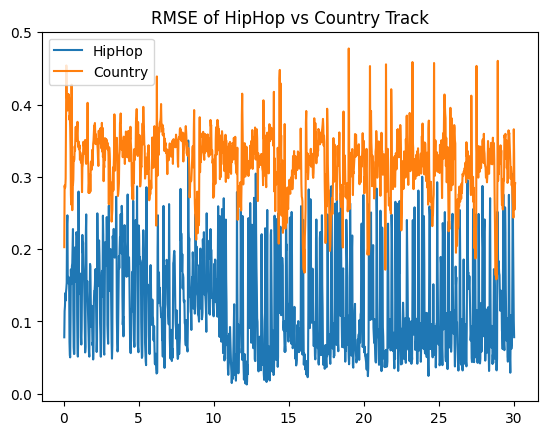

In [191]:
# RMSE for hiphop
hiphop_rmse = librosa.feature.rms(y=hiphop, frame_length=frame_length)
frames = range(1,hiphop_rmse.size+1) #vector of frames as iterable
hiphop_t = librosa.frames_to_time(frames, sr=fs_h, n_fft=frame_length)

# RMSE for country
country_rmse = librosa.feature.rms(y=country, frame_length=frame_length)
frames = range(1,country_rmse.size+1) #vector of frames as iterable
country_t = librosa.frames_to_time(frames, sr=fs_c, n_fft=frame_length)

# plotting
plt.plot(hiphop_t, hiphop_rmse[0], label='HipHop')
plt.plot(country_t, country_rmse[0], label='Country')
plt.legend()
plt.title('RMSE of HipHop vs Country Track')

The RMSE of the signal essentially calculates the average power of the signal over time. This will perceptually describe the loudness of the audio signal over time.

The two lines here barely overlap, so their means are clearly very different, abd the shape of the graphs also appear different. So it seems like the RMS might be a useful feature in our classification.

Text(0.5, 1.0, 'Spectral Centroid of HipHop vs Country Track')

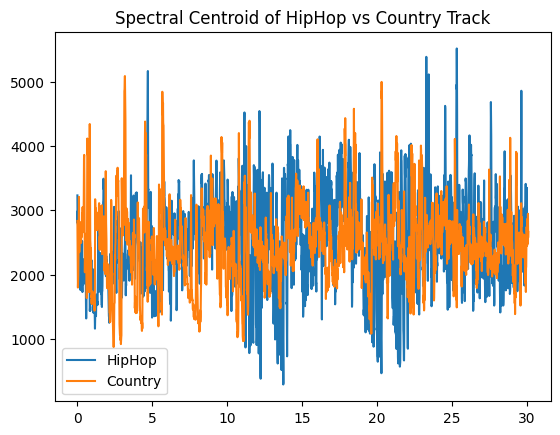

In [192]:
# Spectral Centroid for hiphop
hiphop_centroid = librosa.feature.spectral_centroid(y=hiphop, n_fft=frame_length, hop_length=hop_length)
frames = range(1,hiphop_centroid.size+1) #vector of frames as iterable
hiphop_t = librosa.frames_to_time(frames, sr=fs_h, n_fft=frame_length, hop_length=hop_length)

# Spectral Centroid for country
country_centroid = librosa.feature.spectral_centroid(y=country, n_fft=frame_length, hop_length=hop_length)
frames = range(1,country_centroid.size+1) #vector of frames as iterable
country_t = librosa.frames_to_time(frames, sr=fs_h, n_fft=frame_length, hop_length=hop_length)

# plotting
plt.plot(hiphop_t, hiphop_centroid[0], label='HipHop')
plt.plot(country_t, country_centroid[0], label='Country')
plt.legend()
plt.title('Spectral Centroid of HipHop vs Country Track')

The spectral centroid indicates the center frequency of the audio spectrogram over time. Perceptually this gives an indication
of the timbre of the audio signal over time. Typically, the higher the spectral centroid, the brighter the sound, and the lower
the spectral centroid, the warmer or darker the sound.

The two graphs appear to be different shapes, but they overlap quite a bit so their means will be quite similar. The variance may be useful for classification but probably not the mean.

Text(0.5, 1.0, 'Spectral Flux of HipHop vs Country Track')

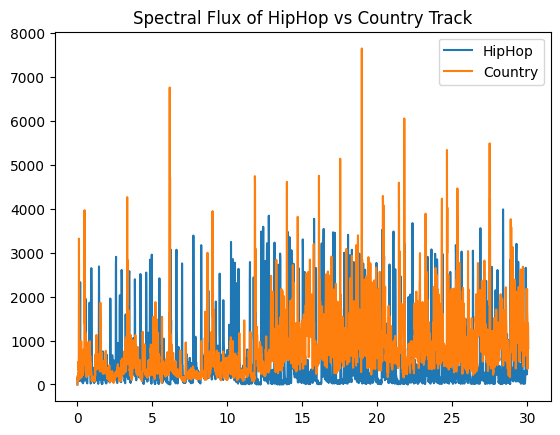

In [193]:
# spectral flux for hiphop
magnitude = np.abs(hiphop_stft)

# Frame-to-frame difference
diff = np.diff(magnitude, axis=0)

# Square and sum across frequency bins
hiphop_flux = np.sum(diff**2, axis=1)

# Pad so output matches frame count
hiphop_flux = np.concatenate(([0], hiphop_flux))

frames = range(1,len(hiphop_flux)+1) #vector of frames as iterable
hiphop_t = librosa.frames_to_time(frames, sr=fs_h, hop_length=256)

# spectral flux for country
magnitude = np.abs(country_stft)

# Frame-to-frame difference
diff = np.diff(magnitude, axis=0)

# Square and sum across frequency bins
country_flux = np.sum(diff**2, axis=1)

# Pad so output matches frame count
country_flux = np.concatenate(([0], country_flux))

frames = range(1,len(country_flux)+1) #vector of frames as iterable
country_t = librosa.frames_to_time(frames, sr=fs_c, hop_length=256)

# plotting
plt.plot(hiphop_t, hiphop_flux, label='HipHop')
plt.plot(country_t, country_flux, label='Country')
plt.legend()
plt.title('Spectral Flux of HipHop vs Country Track')

Spectral flux measures the change in shape of the audio spectrogram. Perceptually, it can also describe the timbre of an audio signal, and can also describe onsets in the signal.

The locations and distributions of the peaks appear in much different places in the track, and the base/average values change a bit throughout the country track, but the mean probably won't be useful for classification. The peaks are much different heights so the variance might be useful for classification. There can probably be other useful features extracted from the spectral flux, but that would require further analysis.

Text(0.5, 1.0, 'Zero Crossing Rate of HipHop vs Country Track')

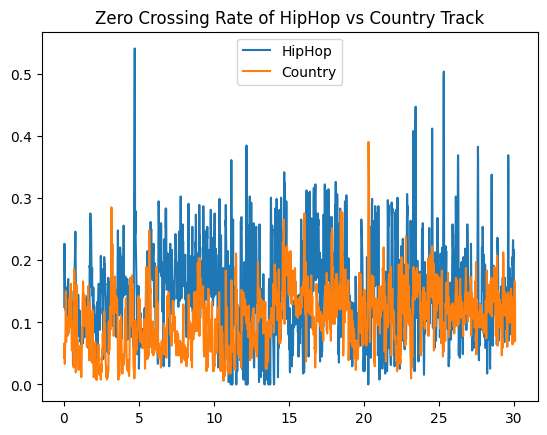

In [194]:
# ZCR for hiphop
hiphop_zcr= librosa.feature.zero_crossing_rate(y=hiphop, frame_length=frame_length, hop_length=hop_length)
frames = range(1,hiphop_centroid.size+1) #vector of frames as iterable
hiphop_t = librosa.frames_to_time(frames, sr=fs_h, n_fft=frame_length, hop_length=hop_length)

# ZCR for country
country_zcr = librosa.feature.zero_crossing_rate(y=country, frame_length=frame_length, hop_length=hop_length)
frames = range(1,country_centroid.size+1) #vector of frames as iterable
country_t = librosa.frames_to_time(frames, sr=fs_h, n_fft=frame_length, hop_length=hop_length)

# plotting
plt.plot(hiphop_t, hiphop_zcr[0], label='HipHop')
plt.plot(country_t, country_zcr[0], label='Country')
plt.legend()
plt.title('Zero Crossing Rate of HipHop vs Country Track')

The zero crossing rate is fairly self explanatory. It describes the frequency at which the signal's value crosses 0. A high ZCR can indicate the presence of predominantly high frequencies, and possibly a more noisy signal. A lower ZCR indicated the presence of predominantly lower frequencies.

The centers of the two lines here seem to be offset, although they do overlap quite a bit. They also seem to have differing widths, so it seems that both the mean and variance might be useful in our classification.

## Part 3: Binomial Logistic Regression (5 points)

Like in activity 7, you will build a binomial classifier with logistic regression. You will use the GTZAN genre dataset 'features_30_sec.csv' this time to classify hiphop vs country music.

### Explore the data and select your features (3 points)

Use graphing and correlation techniques to determine 5 features you will use for your classification.

You must at a minimum create 1 bar graph and 1 box plot in addition to computing the correlation between the features you select.

Construct your Pandas dataframe for your chosen features. Remember you may want to do some scaling and normalization.

In [195]:
raw_data = pd.read_csv('../Datasets/features_30_sec.csv')

genres = ['hiphop', 'country']
data = raw_data[raw_data['label'].isin(genres)]

data.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
200,country.00000.wav,663300,0.384027,0.081182,0.248418,0.000704,2797.844810,354673.043774,2847.551887,105651.317886,...,68.586594,0.615661,54.304928,4.062637,74.334892,0.909476,68.596603,4.095612,73.610832,country
201,country.00001.wav,661760,0.414032,0.079332,0.230516,0.000446,2938.155358,101837.490524,2839.657689,40987.078803,...,37.167381,-2.764677,46.065048,2.824268,48.752991,-1.738780,44.390938,0.974067,48.062492,country
202,country.00002.wav,669680,0.297045,0.097204,0.146586,0.001544,2308.673365,545384.343984,2618.607096,99595.722265,...,37.158360,-4.772855,35.958435,-0.286400,40.287098,-5.357112,43.693214,-1.965473,61.187630,country
203,country.00003.wav,661408,0.376894,0.083747,0.204364,0.001915,2174.033869,570638.884152,2280.888606,207005.343638,...,61.081104,-6.525970,63.754681,-0.034701,47.429501,-1.414051,41.131588,-3.078825,51.753349,country
204,country.00004.wav,661408,0.382781,0.081821,0.209498,0.000802,2966.086095,192897.128750,2848.106749,74510.070234,...,39.297134,-0.166441,43.141171,0.241561,48.237293,-5.440013,33.747955,1.827359,44.118107,country


In [196]:
data.isnull().sum()

filename                   0
length                     0
chroma_stft_mean           0
chroma_stft_var            0
rms_mean                   0
rms_var                    0
spectral_centroid_mean     0
spectral_centroid_var      0
spectral_bandwidth_mean    0
spectral_bandwidth_var     0
rolloff_mean               0
rolloff_var                0
zero_crossing_rate_mean    0
zero_crossing_rate_var     0
harmony_mean               0
harmony_var                0
perceptr_mean              0
perceptr_var               0
tempo                      0
mfcc1_mean                 0
mfcc1_var                  0
mfcc2_mean                 0
mfcc2_var                  0
mfcc3_mean                 0
mfcc3_var                  0
mfcc4_mean                 0
mfcc4_var                  0
mfcc5_mean                 0
mfcc5_var                  0
mfcc6_mean                 0
mfcc6_var                  0
mfcc7_mean                 0
mfcc7_var                  0
mfcc8_mean                 0
mfcc8_var     

In [197]:
data.columns

Index(['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean',
       'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var',
       'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean',
       'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var',
       'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo',
       'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean',
       'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var',
       'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean',
       'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var',
       'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean',
       'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var',
       'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean',
       'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var',
  

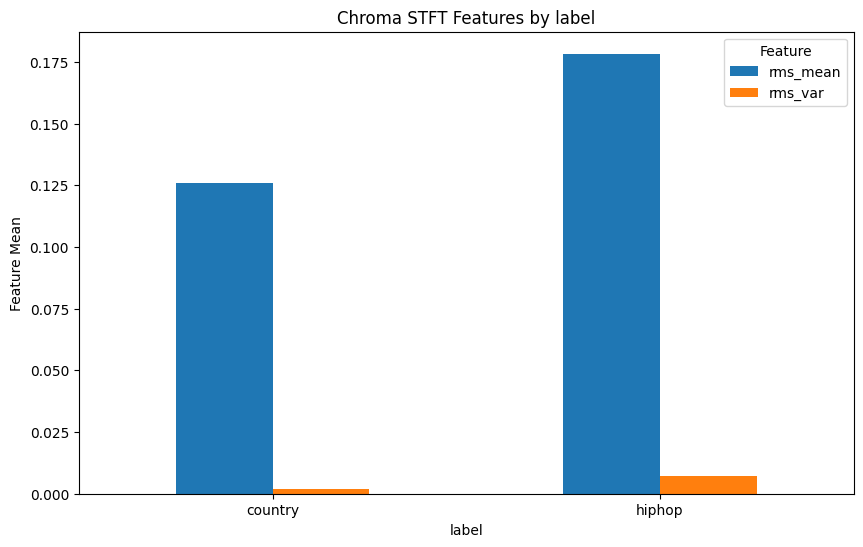

In [198]:
# running through all the mean/variance paired features and keeping ones where both have seemingly significant differences

grouped = data.groupby("label").mean(numeric_only=True)
features = [
    "rms_mean",
    "rms_var"
]

grouped_features = grouped[features]
grouped_features.plot.bar(figsize=(10, 6), title='Chroma STFT Features by label')
plt.ylabel("Feature Mean")
plt.xticks(rotation=0)
plt.legend(title="Feature")
plt.show()

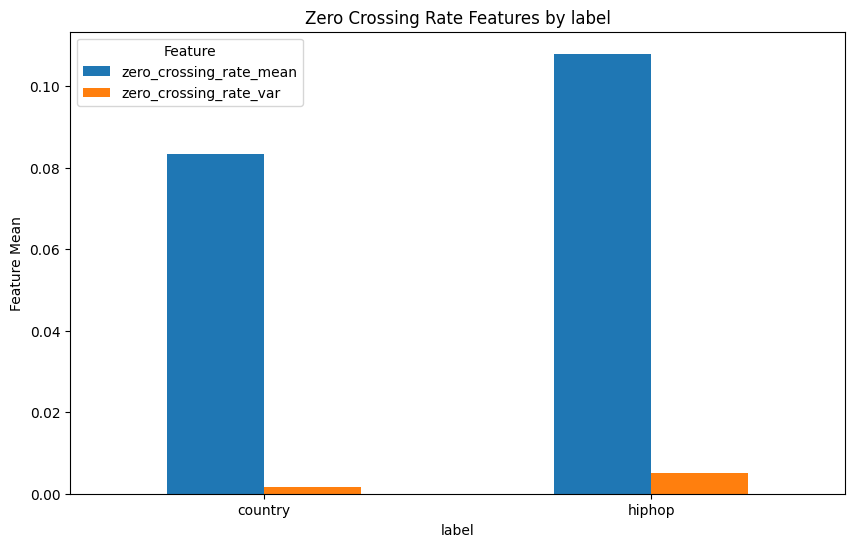

In [199]:
grouped = data.groupby("label").mean(numeric_only=True)
features = [
    'zero_crossing_rate_mean',
    'zero_crossing_rate_var'
]

grouped_features = grouped[features]
grouped_features.plot.bar(figsize=(10, 6), title='Zero Crossing Rate Features by label')
plt.ylabel("Feature Mean")
plt.xticks(rotation=0)
plt.legend(title="Feature")
plt.show()

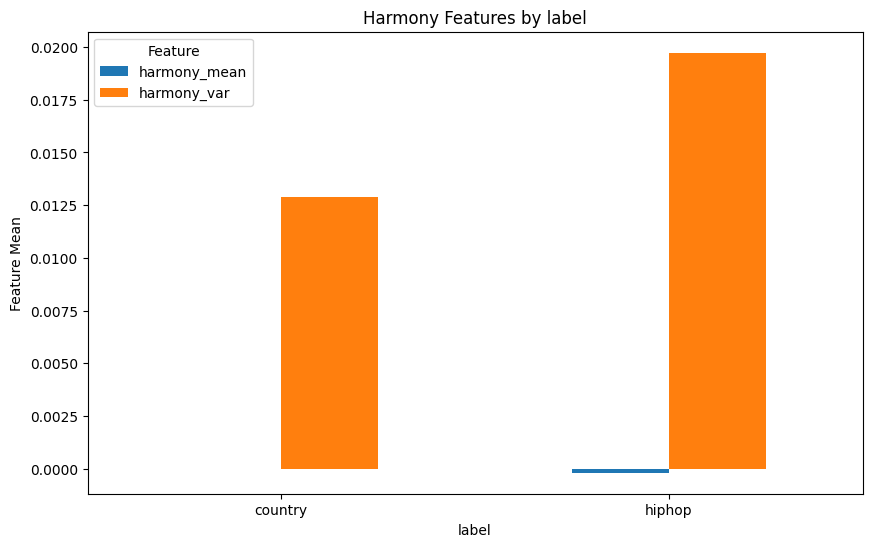

In [200]:
grouped = data.groupby("label").mean(numeric_only=True)
features = [
    'harmony_mean',
    'harmony_var'
]

grouped_features = grouped[features]
grouped_features.plot.bar(figsize=(10, 6), title='Harmony Features by label')
plt.ylabel("Feature Mean")
plt.xticks(rotation=0)
plt.legend(title="Feature")
plt.show()

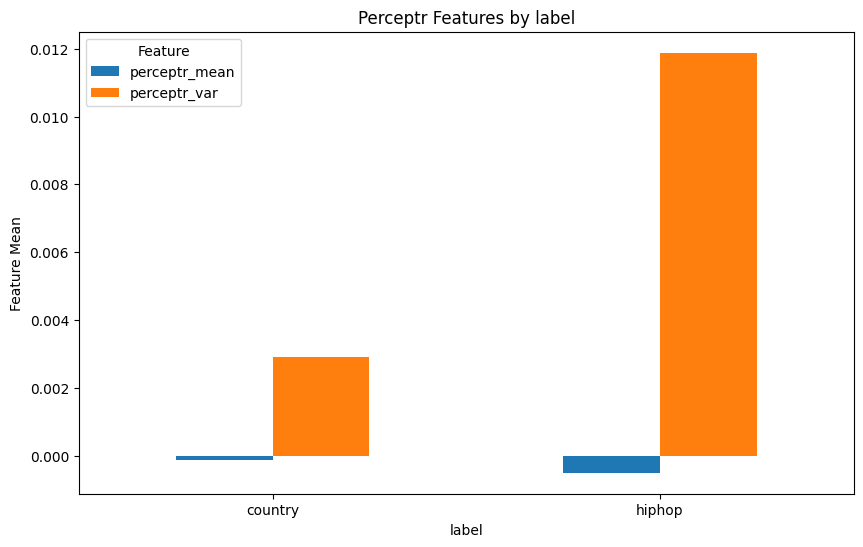

In [201]:
grouped = data.groupby("label").mean(numeric_only=True)
features = [
    'perceptr_mean',
    'perceptr_var'
]

grouped_features = grouped[features]
grouped_features.plot.bar(figsize=(10, 6), title='Perceptr Features by label')
plt.ylabel("Feature Mean")
plt.xticks(rotation=0)
plt.legend(title="Feature")
plt.show()

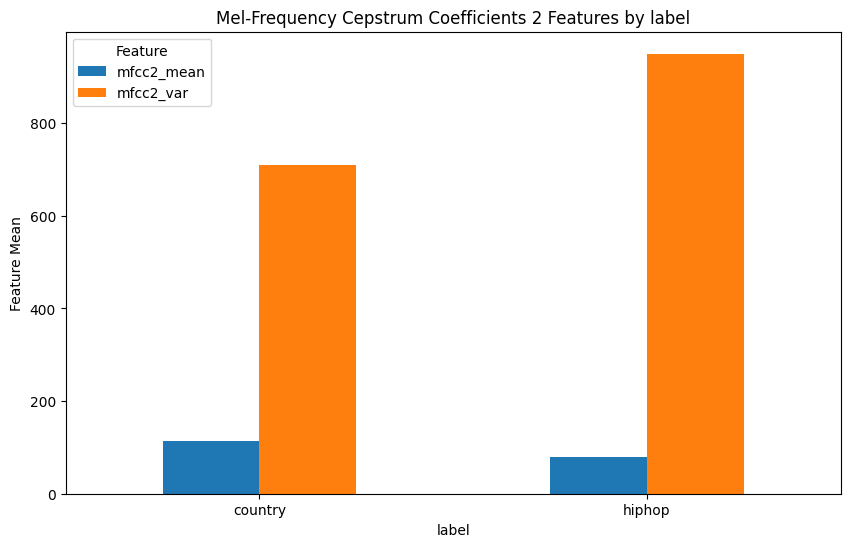

In [202]:
grouped = data.groupby("label").mean(numeric_only=True)
features = [
    'mfcc2_mean',
    'mfcc2_var'
]

grouped_features = grouped[features]
grouped_features.plot.bar(figsize=(10, 6), title='Mel-Frequency Cepstrum Coefficients 2 Features by label')
plt.ylabel("Feature Mean")
plt.xticks(rotation=0)
plt.legend(title="Feature")
plt.show()

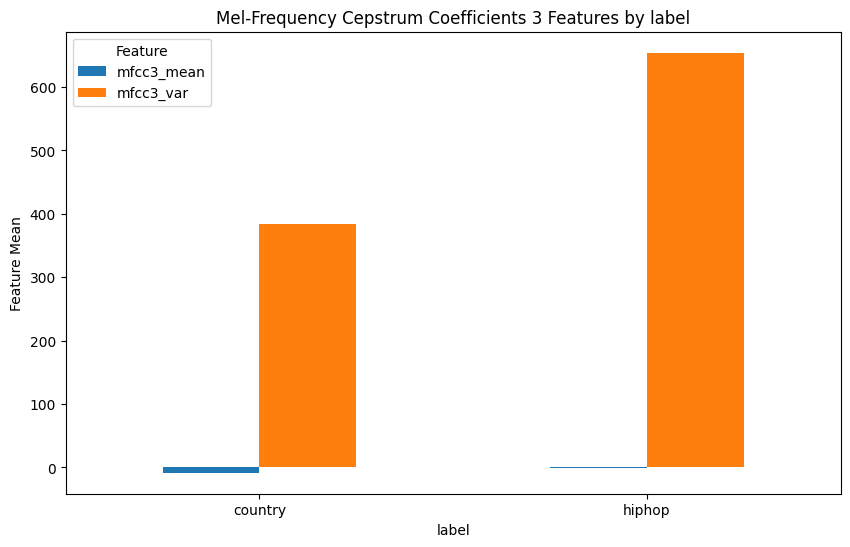

In [203]:
grouped = data.groupby("label").mean(numeric_only=True)
features = [
    'mfcc3_mean',
    'mfcc3_var'
]

grouped_features = grouped[features]
grouped_features.plot.bar(figsize=(10, 6), title='Mel-Frequency Cepstrum Coefficients 3 Features by label')
plt.ylabel("Feature Mean")
plt.xticks(rotation=0)
plt.legend(title="Feature")
plt.show()

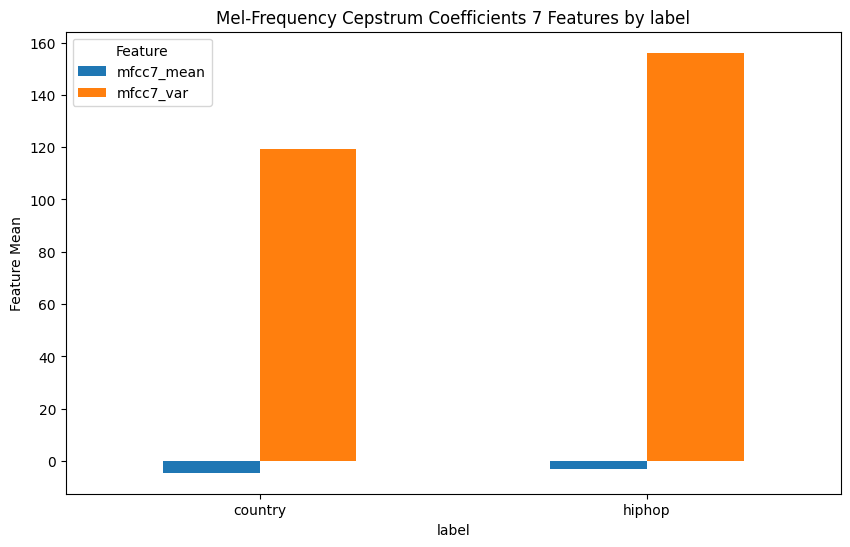

In [204]:
grouped = data.groupby("label").mean(numeric_only=True)
features = [
    'mfcc7_mean',
    'mfcc7_var'
]

grouped_features = grouped[features]
grouped_features.plot.bar(figsize=(10, 6), title='Mel-Frequency Cepstrum Coefficients 7 Features by label')
plt.ylabel("Feature Mean")
plt.xticks(rotation=0)
plt.legend(title="Feature")
plt.show()

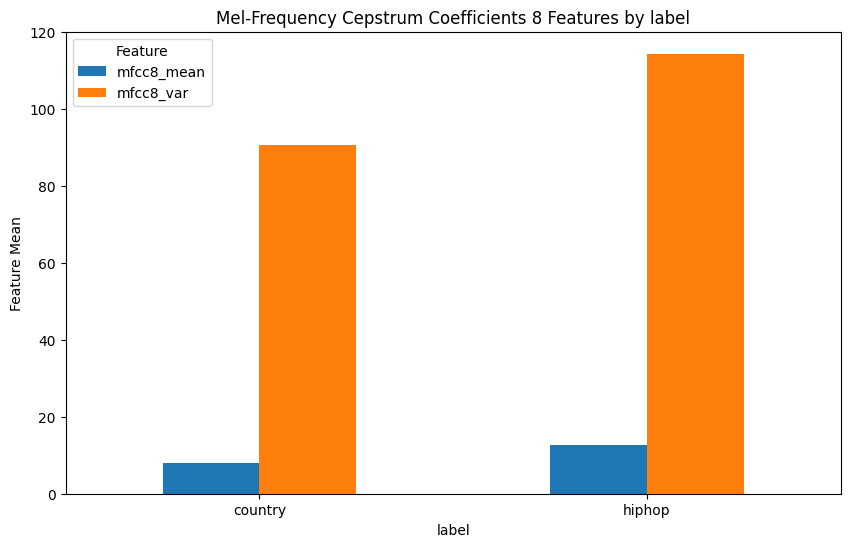

In [205]:
grouped = data.groupby("label").mean(numeric_only=True)
features = [
    'mfcc8_mean',
    'mfcc8_var'
]

grouped_features = grouped[features]
grouped_features.plot.bar(figsize=(10, 6), title='Mel-Frequency Cepstrum Coefficients 8 Features by label')
plt.ylabel("Feature Mean")
plt.xticks(rotation=0)
plt.legend(title="Feature")
plt.show()

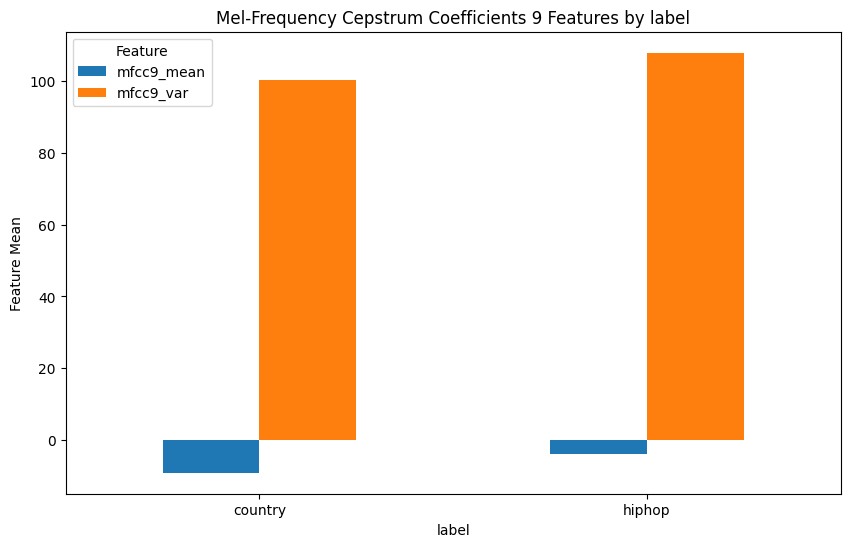

In [206]:
grouped = data.groupby("label").mean(numeric_only=True)
features = [
    'mfcc9_mean',
    'mfcc9_var'
]

grouped_features = grouped[features]
grouped_features.plot.bar(figsize=(10, 6), title='Mel-Frequency Cepstrum Coefficients 9 Features by label')
plt.ylabel("Feature Mean")
plt.xticks(rotation=0)
plt.legend(title="Feature")
plt.show()

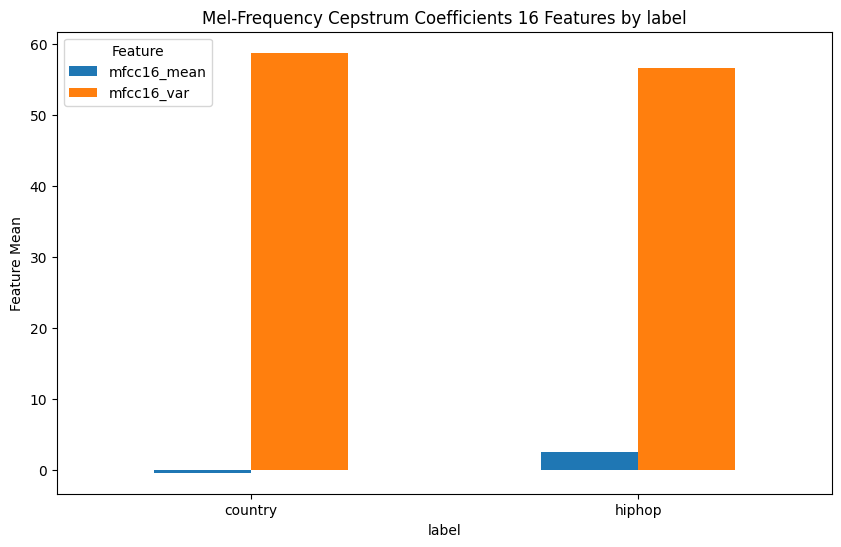

In [207]:
grouped = data.groupby("label").mean(numeric_only=True)
features = [
    'mfcc16_mean',
    'mfcc16_var'
]

grouped_features = grouped[features]
grouped_features.plot.bar(figsize=(10, 6), title='Mel-Frequency Cepstrum Coefficients 16 Features by label')
plt.ylabel("Feature Mean")
plt.xticks(rotation=0)
plt.legend(title="Feature")
plt.show()

<AxesSubplot: title={'center': 'tempo'}, xlabel='label'>

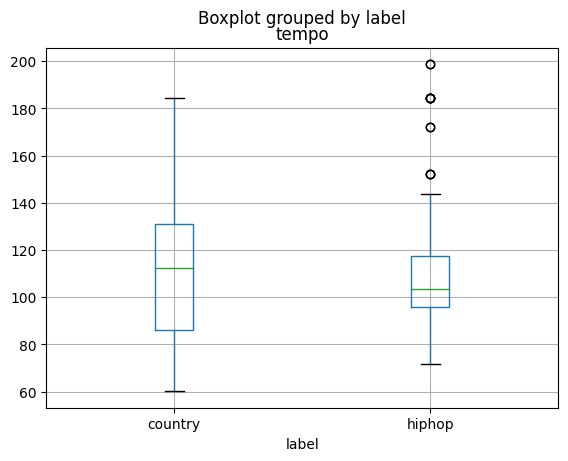

In [208]:
fig, ax = plt.subplots()
data.boxplot(column='tempo', by='label', ax=ax)

# not a super significant difference in the tempo distributions

<AxesSubplot: title={'center': 'rms_mean'}, xlabel='label'>

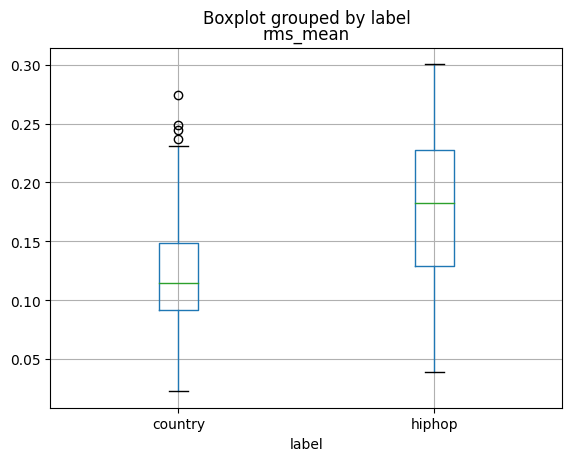

In [209]:
# doing box plots for each individual feature in the mean/variance plots that i kept and keeping only significantly
# differing distributions

fig, ax = plt.subplots()
data.boxplot(column='rms_mean', by='label', ax=ax)

<AxesSubplot: title={'center': 'rms_var'}, xlabel='label'>

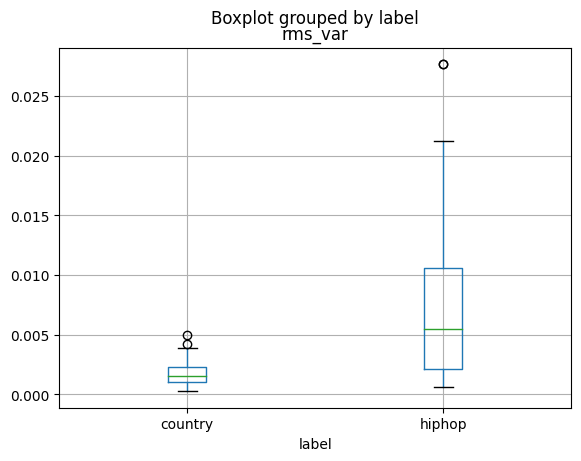

In [210]:
fig, ax = plt.subplots()
data.boxplot(column='rms_var', by='label', ax=ax)

<AxesSubplot: title={'center': 'zero_crossing_rate_mean'}, xlabel='label'>

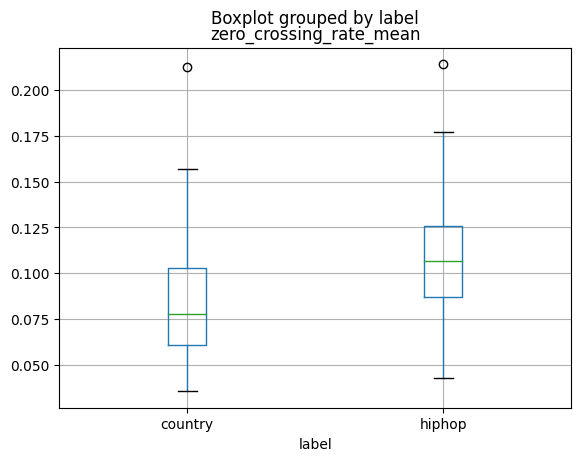

In [211]:
fig, ax = plt.subplots()
data.boxplot(column='zero_crossing_rate_mean', by='label', ax=ax)

<AxesSubplot: title={'center': 'zero_crossing_rate_var'}, xlabel='label'>

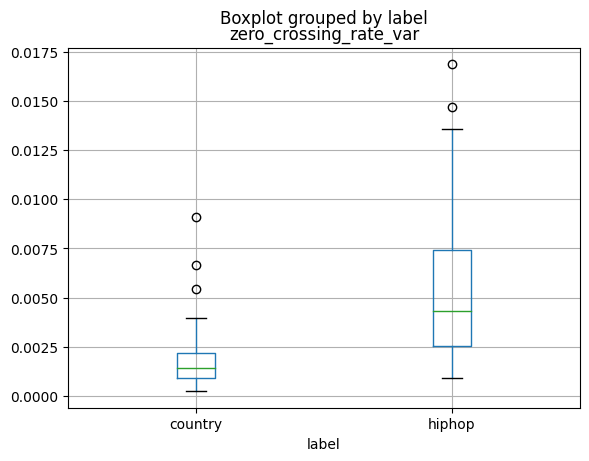

In [212]:
fig, ax = plt.subplots()
data.boxplot(column='zero_crossing_rate_var', by='label', ax=ax)

<AxesSubplot: title={'center': 'harmony_mean'}, xlabel='label'>

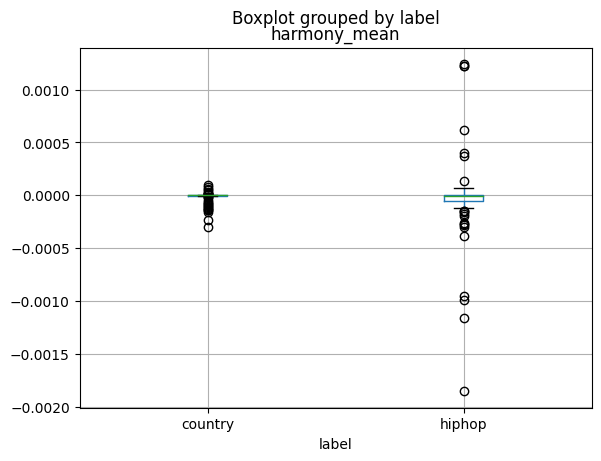

In [213]:
fig, ax = plt.subplots()
filt = data[data['harmony_mean'] > -0.01]
filt.boxplot(column='harmony_mean', by='label', ax=ax)

# this one outlier is so far off that i can't even discern the differences in the distributions
# theres still too many outliers to tell so i'm just gonna say its not reliable enough to use as a feature

<AxesSubplot: title={'center': 'perceptr_var'}, xlabel='label'>

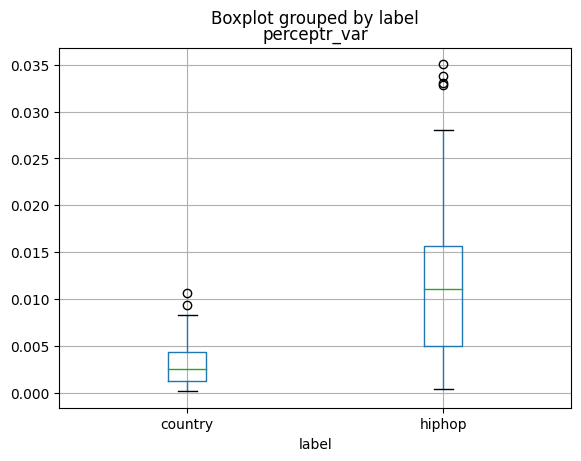

In [214]:
fig, ax = plt.subplots()
data.boxplot(column='perceptr_var', by='label', ax=ax)

<AxesSubplot: title={'center': 'mfcc2_mean'}, xlabel='label'>

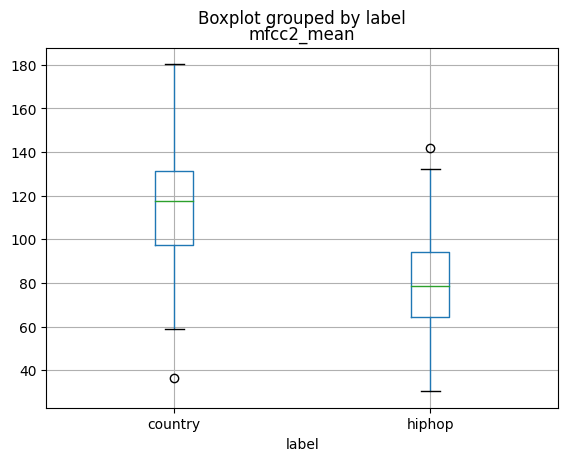

In [215]:
fig, ax = plt.subplots()
data.boxplot(column='mfcc2_mean', by='label', ax=ax)

<AxesSubplot: title={'center': 'mfcc3_var'}, xlabel='label'>

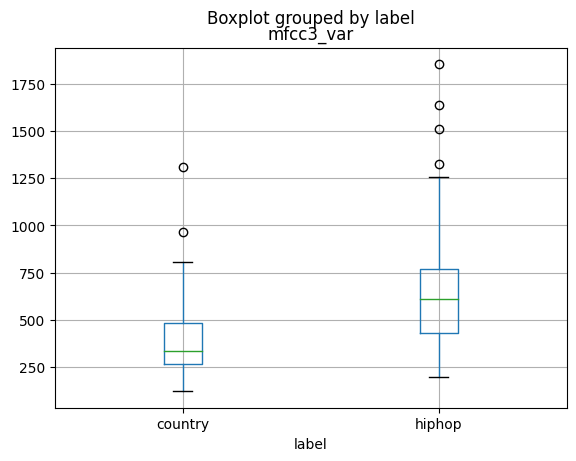

In [216]:
fig, ax = plt.subplots()
data.boxplot(column='mfcc3_var', by='label', ax=ax)

<AxesSubplot: title={'center': 'mfcc4_var'}, xlabel='label'>

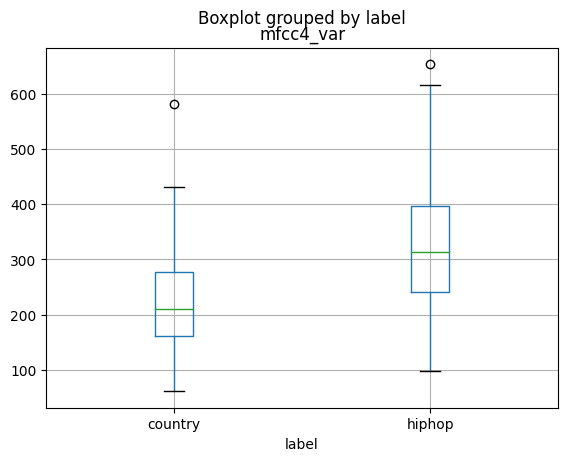

In [217]:
fig, ax = plt.subplots()
data.boxplot(column='mfcc4_var', by='label', ax=ax)

<AxesSubplot: title={'center': 'mfcc9_mean'}, xlabel='label'>

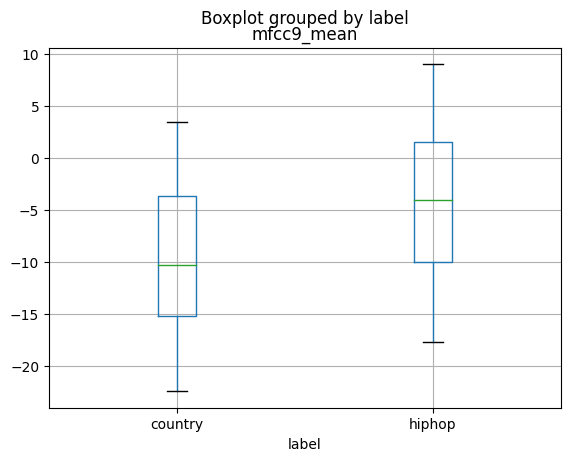

In [218]:
fig, ax = plt.subplots()
data.boxplot(column='mfcc9_mean', by='label', ax=ax)

In [219]:
# the features where the distributions seemed to differ significantly were as followed
# i think keeping the features that are mean/variance pairs that made it through are a good idea
# but i want a better sense of the differences between the distributions of these features
narrowed_features = [
    'rms_mean', 'rms_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var', 'harmony_mean', 'perceptr_var',
    'mfcc2_mean', 'mfcc3_var', 'mfcc4_var', 'mfcc9_mean'
]

# i'm gonna do a binomial test on these distributions to get some sense of how correlated each was, in order to
# pick just 5 features out of these 10. i looked up how to do that for activity 7 and i'm using it again here.

hiphop = data[data['label'] == 'hiphop']
country = data[data['label'] == 'country']

p = []

for feature in narrowed_features:
    stat, p_value = ttest_ind(hiphop[feature], country[feature])
    p.append(p_value)

analysis = pd.DataFrame({'feature': narrowed_features, 'p_value': p})
analysis.sort_values(by=['p_value'], ascending=True, inplace=True)
analysis

# the rms and zero crossing rate mean and variance are a bit scattered here, but the feature with the lowest p-value by far
# is the perceptr_var. so i think that should go into the final features. i'm gonna decide to keep the RMS mean/var, ZCR
# mean/var, and perceptr var.

,feature,p_value
5,perceptr_var,5.213281e-21
6,mfcc2_mean,3.557669e-18
3,zero_crossing_rate_var,4.990621e-18
1,rms_var,1.128950e-16
7,mfcc3_var,4.196178e-12
8,mfcc4_var,1.121304e-10
0,rms_mean,1.553706e-10
2,zero_crossing_rate_mean,7.745083e-08
9,mfcc9_mean,6.333036e-07
4,harmony_mean,2.758791e-01


In [220]:
# convert the label into a binary feature
selected_features = ['perceptr_var', 'rms_mean', 'rms_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var']

labels = pd.get_dummies(data['label'], drop_first=True)
data_narrow = data[selected_features]
data_dmy = pd.concat([data_narrow,labels],axis=1)
data_dmy

,perceptr_var,rms_mean,rms_var,zero_crossing_rate_mean,zero_crossing_rate_var,hiphop
200,0.004807,0.248418,0.000704,0.107205,0.001750,0
201,0.005504,0.230516,0.000446,0.126988,0.000877,0
202,0.002957,0.146586,0.001544,0.074162,0.003938,0
203,0.005625,0.204364,0.001915,0.102564,0.002367,0
204,0.004010,0.209498,0.000802,0.124161,0.001263,0
...,...,...,...,...,...,...
495,0.003931,0.103468,0.001790,0.157556,0.002893,1
496,0.004686,0.110829,0.001377,0.083117,0.000915,1
497,0.003001,0.118497,0.001741,0.116005,0.004182,1
498,0.003245,0.119111,0.002180,0.100706,0.003607,1


### Train/Test Split

Use sklearn to split your data into testing and training sets. Remember you will need to define your categories, predictors, and test size. Use 30% test size.

In [221]:
scaler = StandardScaler()
scaler.fit(data_dmy)

data_norm = scaler.transform(data_dmy)
data_norm

array([[-0.34778408,  1.59123547, -0.74159052,  0.34560443, -0.55420087,
        -1.        ],
       [-0.25422512,  1.29528389, -0.79203627,  0.93929464, -0.83714032,
        -1.        ],
       [-0.59577927, -0.0922348 , -0.57765356, -0.64598512,  0.15504087,
        -1.        ],
       ...,
       [-0.5899079 , -0.55659859, -0.53912562,  0.60969634,  0.23407435,
         1.        ],
       [-0.55721556, -0.54645489, -0.45339496,  0.15057737,  0.04752165,
         1.        ],
       [ 1.0536894 ,  0.0252179 ,  2.03204245,  0.17485187,  0.29342334,
         1.        ]])

In [222]:
categories = data_norm[:,5]
predictors = data_norm[:,:5]

pred_train, pred_test, cat_train, cat_test = train_test_split(predictors, categories, test_size=0.3)

### Train the Model and Evaluate (2 points)

Train the model using logistic regression.

Calculate the confusion matrix (and view as a data frame). Calculate the accuracy, precision, recall, and F1 scores.

Explain what the confusion matrix and accuracy tell us about your model.

In [223]:
model = LogisticRegression(solver='lbfgs')
model.fit(pred_train, cat_train)
predictions = model.predict(pred_test)

In [224]:
# the confusion matrix describes predicted vs actual classifications
# the more common error type in this case is incorrectly classifying rock as pop
cm = confusion_matrix(cat_test, predictions)
pd.DataFrame(cm, columns=['Country','HipHop'], index=['Predicts_Country','Predicts_HipHop'])

,Country,HipHop
Predicts_Country,24,5
Predicts_HipHop,6,25


In [225]:
# accuracy is the proportion of overall correct answers
accuracy = (cm[0,0] + cm[1,1]) / cm.sum()

# precision is the proportion of predicted positives are correct
precision = cm[1,1] / cm[:,1].sum()

# recall is the proportion of actual positives were predicted correctly
recall = cm[1,1] / cm[1].sum()

f1 = 2*precision*recall/(precision+recall)

print('Accuracy: %.4f\nPrecision: %.4f\nRecall: %.4f\nF1: %.4f' % (accuracy, precision, recall, f1))

Accuracy: 0.8167
Precision: 0.8333
Recall: 0.8065
F1: 0.8197


I already explained each of the analysis quantities above, but overall the model is passable but 82% isn't great accuracy for a binary classifier, and its much lower than the almost 90% accuracy from my activity 7 classifier. This could be that the country vs. hiphop classification is a bit more of a challenging problem, or maybe the selected features are less than ideal.

GenAI Usage Statement:

- Tool used and date of access
- The input (prompt) you provided
- A copy of the output
- A description of how you used or edited the AI-generated content